# BERT

In [2]:
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

In [3]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

In [4]:
model = BertForQuestionAnswering.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
tokenizer = BertTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Embeddings

In [6]:
question = "When was the first dvd released?"
answer_document = "The first DVD (Digital Versatile Disc) was released on March 24, 1997. It was a movie titled 'Twister' and was released in Japan."

In [12]:
encoding = tokenizer(text=question,text_pair=answer_document)

In [13]:
print(encoding)

{'input_ids': [101, 2043, 2001, 1996, 2034, 4966, 2207, 1029, 102, 1996, 2034, 4966, 1006, 3617, 22979, 5860, 1007, 2001, 2207, 2006, 2233, 2484, 1010, 2722, 1012, 2009, 2001, 1037, 3185, 4159, 1005, 9792, 2121, 1005, 1998, 2001, 2207, 1999, 2900, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [15]:
inputs = encoding['input_ids']
sentence_embedding = encoding['token_type_ids']
tokens = tokenizer.convert_ids_to_tokens(inputs)

In [16]:
tokenizer.decode(101)

'[CLS]'

In [17]:
tokenizer.decode(102)

'[SEP]'

In [18]:
output = model(input_ids = torch.tensor([inputs]), token_type_ids = torch.tensor([sentence_embedding]))

# Model Output

In [20]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

print(start_index)
print(end_index)

tensor(20)
tensor(23)


In [21]:
answer = ' '.join(tokens[start_index:end_index+1])
print(answer)

march 24 , 1997


In [24]:
import matplotlib as plt
import seaborn as sns

In [25]:
s_scores = output.start_logits.detach().numpy().flatten()
e_scores = output.end_logits.detach().numpy().flatten()

In [27]:
token_labels = []
for (i, token) in enumerate(tokens):
  token_labels.append('{:} - {:>2}'.format(token, i))

/tmp/ipykernel_1355/1538046351.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


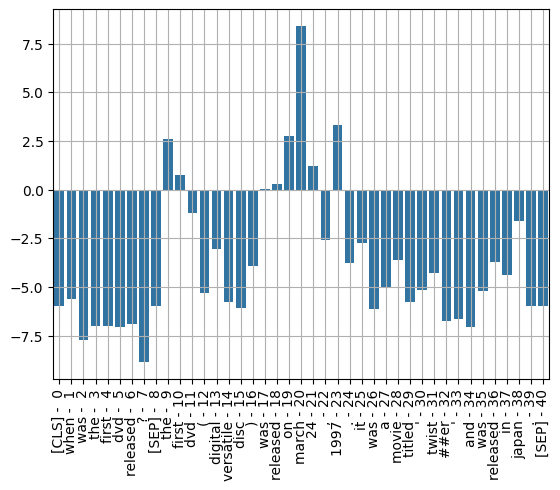

In [28]:
ax = sns.barplot(x=token_labels, y=s_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

/tmp/ipykernel_1355/365763533.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


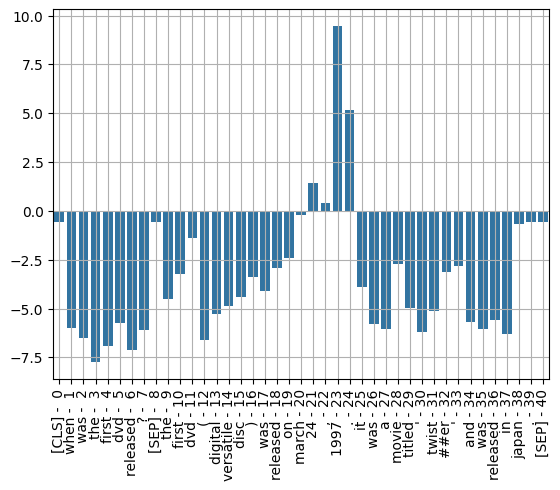

In [29]:
ax = sns.barplot(x=token_labels, y=e_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

In [46]:
sunset_motors_context = '''
Sunset Motors is a premier automobile dealership strategically located in the heart of downtown Miami, Florida. Spanning over 50,000 square feet, our state-of-the-art facility is one of the largest in the region, featuring a massive climate-controlled showroom and an advanced service center. We specialize in high-end performance and luxury vehicles, offering an extensive selection of Porsche, BMW, and Audi models. Whether you are looking for a sleek sports car or a sophisticated family SUV, our expansive inventory and prime location make Sunset Motors the ultimate destination for automotive enthusiasts.
'''

In [51]:
def faq_bot(question):
  context = sunset_motors_context
  input_ids = tokenizer.encode(question, context)
  tokens = tokenizer.convert_ids_to_tokens(input_ids)
  sep_idx = input_ids.index(tokenizer.sep_token_id)
  num_seg_a = sep_idx+1
  num_seg_b = len(input_ids) - num_seg_a
  segment_ids = [0]*num_seg_a + [1]*num_seg_b
  output = model(torch.tensor([input_ids]), token_type_ids=torch.tensor([segment_ids]))
  answer_start = torch.argmax(output.start_logits)
  answer_end = torch.argmax(output.end_logits)
  if answer_end >= answer_start:
    answer = ' '.join(tokens[answer_start:answer_end+1])
  else:
    answer = "I am unable to find the answer to this question."
  corrected_answer = ''
  for word in answer.split():
    if word[0:2] == '##':
      corrected_answer += word[2:]
    else:
      corrected_answer += ' ' + word
  return corrected_answer

In [48]:
faq_bot("Where is the dealership located?")

' downtown miami , florida'

In [49]:
faq_bot("What make of cars are available?")

' porsche , bmw , and audi models'

In [50]:
faq_bot("How large is the dealership?")

' over 50 , 000 square feet'